In [8]:
from google.colab import files
import io
import pandas as pd

# This will prompt you to select the file from your local drive
uploaded = files.upload()

# Get the filename (it picks the first file you uploaded)
filename = list(uploaded.keys())[0]

# Load the data into a DataFrame
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Successfully loaded: {filename}")
df.head()

Saving online_shoppers_intention.csv to online_shoppers_intention (1).csv
Successfully loaded: online_shoppers_intention (1).csv


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [9]:
# Check for missing values and fill them if necessary
df = df.fillna(df.median(numeric_only=True))

# Identify non-numeric columns (categorical data)
categorical_cols = df.select_dtypes(include=['object']).columns

# Convert text labels to numbers (0, 1, 2...)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical columns encoded. Updated data preview:")
df.head()

Categorical columns encoded. Updated data preview:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,False


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# REPLACE 'will_purchase' with your actual column name for the result
target_column = 'Revenue'

X = df.drop(target_column, axis=1)
y = df[target_column]

# Splitting data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features so they have a similar range
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Features: {list(X.columns)}")
print("Data split and scaled successfully.")

Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Data split and scaled successfully.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize the AI Model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Show results
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 86.90%

Detailed Report:
              precision    recall  f1-score   support

       False       0.88      0.97      0.93      2055
        True       0.73      0.34      0.47       411

    accuracy                           0.87      2466
   macro avg       0.80      0.66      0.70      2466
weighted avg       0.86      0.87      0.85      2466



In [17]:
import numpy as np

# Create a list representing one customer's data
# Ensure the values are in the same order as your CSV columns!
# The features are: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
sample_customer = [[0, 0.0, 0, 0.0, 1, 0.0, 0.2, 0.2, 0.0, 0.0, 2, 1, 1, 1, 1, 2, False]]

# Scale the input
# The UserWarning 'X does not have valid feature names' occurs because sample_customer is a numpy array
# and StandardScaler was fitted on a DataFrame. For a single prediction, this is usually harmless,
# but you can explicitly convert sample_customer to a DataFrame with column names if you want to suppress the warning.
sample_scaled = scaler.transform(sample_customer)

# Predict
prediction = model.predict(sample_scaled)
probability = model.predict_proba(sample_scaled)[0][1]

if prediction[0] == True:
    print(f"Result: High Likelihood of Purchase ({probability:.2%})")
else:
    print(f"Result: Unlikely to Purchase ({probability:.2%})")

Result: Unlikely to Purchase (0.24%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Model Accuracy: {accuracy:.2%}")
print("Interpretation: The model correctly predicted the outcome for " + str(round(accuracy*100)) + "% of the customers in the test set.")

Overall Model Accuracy: 86.90%
Interpretation: The model correctly predicted the outcome for 87% of the customers in the test set.


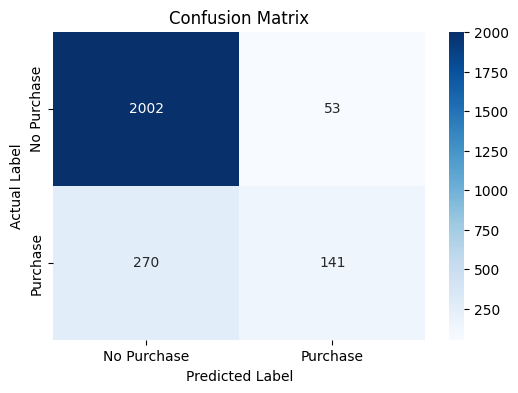

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it using a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Purchase', 'Purchase'], yticklabels=['No Purchase', 'Purchase'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [15]:
from sklearn.metrics import classification_report

# Print the detailed metrics
report = classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase'])
print("--- Classification Report ---")
print(report)

--- Classification Report ---
              precision    recall  f1-score   support

 No Purchase       0.88      0.97      0.93      2055
    Purchase       0.73      0.34      0.47       411

    accuracy                           0.87      2466
   macro avg       0.80      0.66      0.70      2466
weighted avg       0.86      0.87      0.85      2466



In [19]:
import numpy as np

# Change these numbers to test different customer profiles
# Ensure the values are in the same order as your CSV columns!
# The features are: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
new_data = np.array([[0, 0.0, 0, 0.0, 1, 0.0, 0.2, 0.2, 0.0, 0.0, 2, 1, 1, 1, 1, 2, False]])

# 1. Scale the input data using the same scaler we used for training
# The UserWarning 'X does not have valid feature names' occurs because new_data is a numpy array
# and StandardScaler was fitted on a DataFrame. For a single prediction, this is usually harmless,
# but you can explicitly convert new_data to a DataFrame with column names if you want to suppress the warning.
new_data_scaled = scaler.transform(new_data)

# 2. Predict the category (0 or 1)
prediction = model.predict(new_data_scaled)

# 3. Predict the probability (0.0 to 1.0)
probability = model.predict_proba(new_data_scaled)[0][1]

# Display Result
print(f"Customer Data: {new_data[0]}")
if prediction[0] == True:
    print(f"Prediction: LIKELY TO PURCHASE")
else:
    print(f"Prediction: UNLIKELY TO PURCHASE")

print(f"Purchase Probability: {probability:.2%}")

Customer Data: [0.  0.  0.  0.  1.  0.  0.2 0.2 0.  0.  2.  1.  1.  1.  1.  2.  0. ]
Prediction: UNLIKELY TO PURCHASE
Purchase Probability: 0.24%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
